<a href="https://colab.research.google.com/github/rebecca-jf/PhD-project-code/blob/main/Y_Maze_Optomotor_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

!pip install -q ultralytics
from ultralytics import YOLO

!pip install -q ipyevents
import io
import ipywidgets as widgets

from IPython.display import display
from ipyevents import Event
from google.colab import output

output.enable_custom_widget_manager()



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 2.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


video found: /content/drive/MyDrive/Y-maze handedness/bee_0415_bee5_hand_opto_2026-04-15_23-15-32.mp4
frames per second: 9.88210622320898
frame count: 792
image size: 4056 x 3040 pixel
video duration: 80.14 seconds


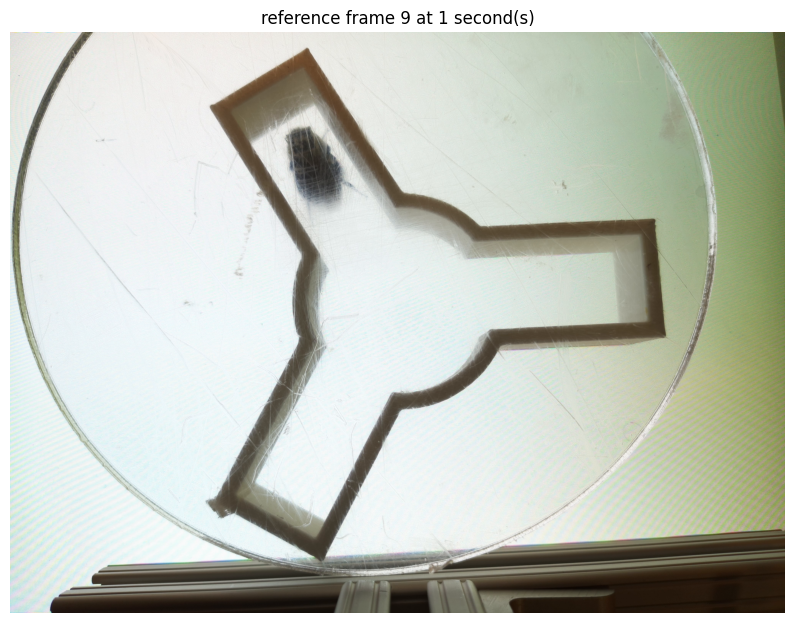

Results folder: /content/drive/MyDrive/Y-maze handedness/results


In [274]:
# choose video, does it exist?

video_path = Path("/content/drive/MyDrive/Y-maze handedness/bee_0415_bee5_hand_opto_2026-04-15_23-15-32.mp4")

if not video_path.exists():
    raise FileNotFoundError(
        f"video was not found: {video_path}"
    )
print("video found:", video_path)

# open the video and read video information

video = cv.VideoCapture(str(video_path))

if not video.isOpened():
    raise ValueError("the video could not be opened")

fps = video.get(cv.CAP_PROP_FPS)
frame_count = int(video.get(cv.CAP_PROP_FRAME_COUNT))
frame_width = int(video.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(video.get(cv.CAP_PROP_FRAME_HEIGHT))

if fps <= 0:
    raise ValueError("frame rate could not be determined")

duration_seconds = frame_count / fps

print("frames per second:", fps)
print("frame count:", frame_count)
print("image size:", frame_width, "x", frame_height, "pixel")
print("video duration:", round(duration_seconds, 2), "seconds")


# read and show reference frame

reference_time_seconds = 1
reference_frame_number = int(reference_time_seconds * fps)

video.set(cv.CAP_PROP_POS_FRAMES, reference_frame_number)
success, frame = video.read()

if not success:
    raise ValueError("reference frame could not be read")

reference_frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(reference_frame_rgb)
plt.title(
    f"reference frame {reference_frame_number} "
    f"at {reference_time_seconds} second(s)"
)
plt.axis("off")
plt.show()

# define results folder

results_folder = Path(
    "/content/drive/MyDrive/"
    "Y-maze handedness/results"
)

results_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Results folder:", results_folder)


In [275]:
video_quality = input(
    "Video quality (usable / limited / exclude): "
)
print(video_quality)

Video quality (usable / limited / exclude): usable
usable


YOLO model found: /content/drive/MyDrive/ymaze2_model.pt
Number of detections: 1

Detection 1
Class      : bee
Confidence : 0.728
Bounding box: (1400.5, 491.4) to (1807.1, 914.7)


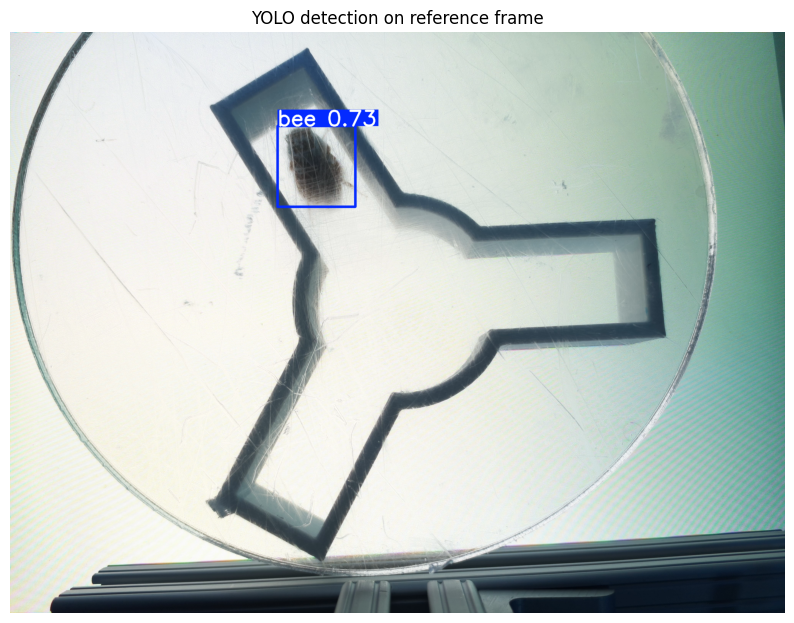

In [276]:
# Load trained YOLO model

model_path = Path(
    "/content/drive/MyDrive/ymaze2_model.pt"
)

if not model_path.exists():
    raise FileNotFoundError(
        f"YOLO model was not found: {model_path}"
    )

print("YOLO model found:", model_path)


model = YOLO(str(model_path))


# Run YOLO on the reference frame

results = model.predict(
    source=reference_frame_rgb,
    conf=0.25,
    verbose=False
)

result = results[0]


# Inspect detections

if result.boxes is None or len(result.boxes) == 0:

    print("No bee was detected in the reference frame.")

else:

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    class_ids = result.boxes.cls.cpu().numpy().astype(int)

    print("Number of detections:", len(boxes))

    for detection_number, (box, confidence, class_id) in enumerate(
        zip(boxes, confidences, class_ids),
        start=1
    ):

        x_min, y_min, x_max, y_max = box
        class_name = model.names[class_id]

        print(f"\nDetection {detection_number}")
        print(f"Class      : {class_name}")
        print(f"Confidence : {confidence:.3f}")
        print(
            f"Bounding box: "
            f"({x_min:.1f}, {y_min:.1f}) to "
            f"({x_max:.1f}, {y_max:.1f})"
        )


# Display annotated reference frame

annotated_frame = result.plot()

annotated_frame_rgb = cv.cvtColor(
    annotated_frame,
    cv.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_frame_rgb)
plt.title("YOLO detection on reference frame")
plt.axis("off")
plt.show()

In [277]:
# Convert reference frame to PNG bytes for the interactive widget

success_png, encoded_frame = cv.imencode(
    ".png",
    cv.cvtColor(reference_frame_rgb, cv.COLOR_RGB2BGR)
)

if not success_png:
    raise ValueError("Reference frame could not be converted to PNG.")

image_bytes = encoded_frame.tobytes()


# Create clickable image widget

image_widget = widgets.Image(
    value=image_bytes,
    format="png"
)

instruction = widgets.HTML(
    value="<b>Click on the center of the Y-maze.</b>"
)

status = widgets.Output()

display(instruction, image_widget, status)

# Points must be clicked in this order
  # center as the middle of the Y maze
  # A is the start arm where the bee sits in at the beginning
  # B is the next arm in clockwise direction from A
  # C is the next arm in clockwise direction from B

point_names = ["center", "A", "B", "C"]

calibration_points = {}

click_event = Event(
    source=image_widget,
    watched_events=["click"]
)


def record_calibration_point(event):
    point_number = len(calibration_points)

    # Stop after all four points have been recorded
    if point_number >= len(point_names):
        return

    point_name = point_names[point_number]

    x_coordinate = int(round(event["dataX"]))
    y_coordinate = int(round(event["dataY"]))

    calibration_points[point_name] = (
        x_coordinate,
        y_coordinate
    )

    with status:
        print(
            f"{point_name}: "
            f"x = {x_coordinate}, y = {y_coordinate}"
        )

    next_point_number = len(calibration_points)

    if next_point_number < len(point_names):
        next_point_name = point_names[next_point_number]

        instruction.value = (
            f"<b>Now click on: {next_point_name}</b>"
        )

    else:
        instruction.value = (
            "<b>Calibration complete: "
            "center, A, B and C were recorded.</b>"
        )

        click_event.watched_events = []


click_event.on_dom_event(record_calibration_point)

HTML(value='<b>Click on the center of the Y-maze.</b>')

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x0f\xd8\x00\x00\x0b\xe0\x08\x02\x00\x00\x00\x7f\x94\…

Output()

In [278]:
calibration_points

{'center': (2028, 1405),
 'A': (1419, 496),
 'B': (3155, 1348),
 'C': (1480, 2449)}

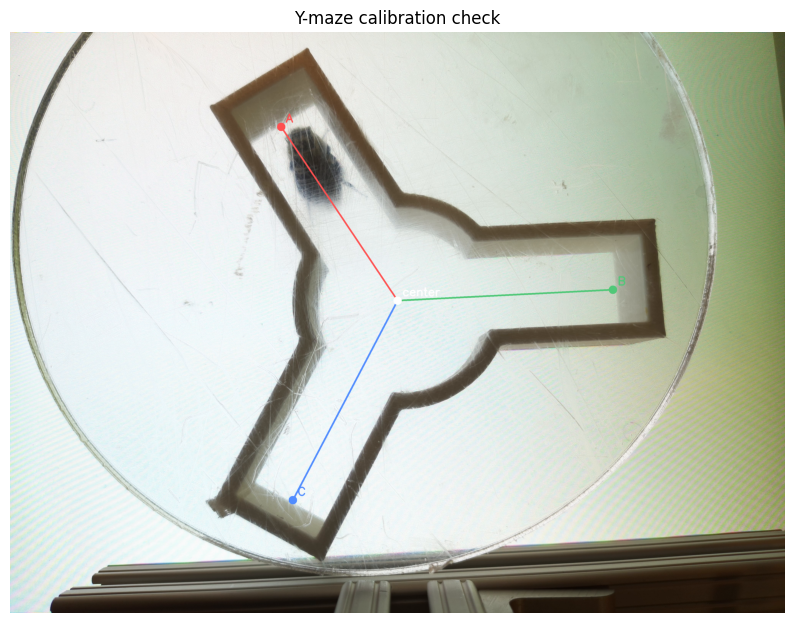

In [279]:
# Create a copy so the original reference frame remains unchanged

calibration_check = reference_frame_rgb.copy()

point_styles = {
    "center": (255, 255, 255),
    "A": (255, 80, 80),
    "B": (80, 200, 120),
    "C": (80, 140, 255)
}


# Draw lines from the center to each arm

center_point = calibration_points["center"]

for arm_name in ["A", "B", "C"]:
    cv.line(
        calibration_check,
        center_point,
        calibration_points[arm_name],
        point_styles[arm_name],
        thickness=8
    )


# Draw and label all four points

for point_name, point in calibration_points.items():
    color = point_styles[point_name]

    cv.circle(
        calibration_check,
        point,
        radius=22,
        color=color,
        thickness=-1
    )

    cv.putText(
        calibration_check,
        point_name,
        (point[0] + 25, point[1] - 25),
        cv.FONT_HERSHEY_SIMPLEX,
        2,
        color,
        thickness=5
    )


plt.figure(figsize=(10, 8))
plt.imshow(calibration_check)
plt.title("Y-maze calibration check")
plt.axis("off")
plt.show()

In [280]:
# Prepare Y-maze geometry

center = np.array(calibration_points["center"], dtype=float)

arm_points = {
    "A": np.array(calibration_points["A"], dtype=float),
    "B": np.array(calibration_points["B"], dtype=float),
    "C": np.array(calibration_points["C"], dtype=float)
}

# Direction vector from center toward each arm
arm_vectors = {
    arm_name: arm_point - center
    for arm_name, arm_point in arm_points.items()
}

# Length from center to each clicked arm point
arm_lengths = {
    arm_name: np.linalg.norm(vector)
    for arm_name, vector in arm_vectors.items()
}

print("Arm lengths in pixels:")
for arm_name, length in arm_lengths.items():
    print(f"{arm_name}: {length:.1f}")

mean_arm_length = np.mean(list(arm_lengths.values()))

center_radius = 0.43 * mean_arm_length                          #adjust value for new camera positioning
maximum_maze_radius = 1.15 * max(arm_lengths.values())

print(f"Center radius: {center_radius:.1f} pixels")
print(f"Maximum maze radius: {maximum_maze_radius:.1f} pixels")

Arm lengths in pixels:
A: 1094.1
B: 1128.4
C: 1179.1
Center radius: 487.6 pixels
Maximum maze radius: 1355.9 pixels


In [281]:
# zone classification

def classify_maze_zone(
    x,
    y,
    center,
    arm_vectors,
    center_radius,
    maximum_maze_radius,
    maximum_angle_degrees=50
):
    """
    Classify one x-y position as:
    center, A, B, C, outside, or missing.
    """

    if pd.isna(x) or pd.isna(y):
        return "missing"

    position = np.array([x, y], dtype=float)
    position_vector = position - center

    distance_from_center = np.linalg.norm(position_vector)

    # Position lies in the central decision zone
    if distance_from_center <= center_radius:
        return "center"

    # Position lies clearly outside the calibrated maze
    if distance_from_center > maximum_maze_radius:
        return "outside"

    best_arm = None
    smallest_angle = np.inf

    for arm_name, arm_vector in arm_vectors.items():

        cosine_value = np.dot(
            position_vector,
            arm_vector
        ) / (
            np.linalg.norm(position_vector)
            * np.linalg.norm(arm_vector)
        )

        # Avoid small numerical errors outside the range -1 to 1
        cosine_value = np.clip(cosine_value, -1, 1)

        angle_degrees = np.degrees(
            np.arccos(cosine_value)
        )

        if angle_degrees < smallest_angle:
            smallest_angle = angle_degrees
            best_arm = arm_name

    if smallest_angle <= maximum_angle_degrees:
        return best_arm

    return "outside"

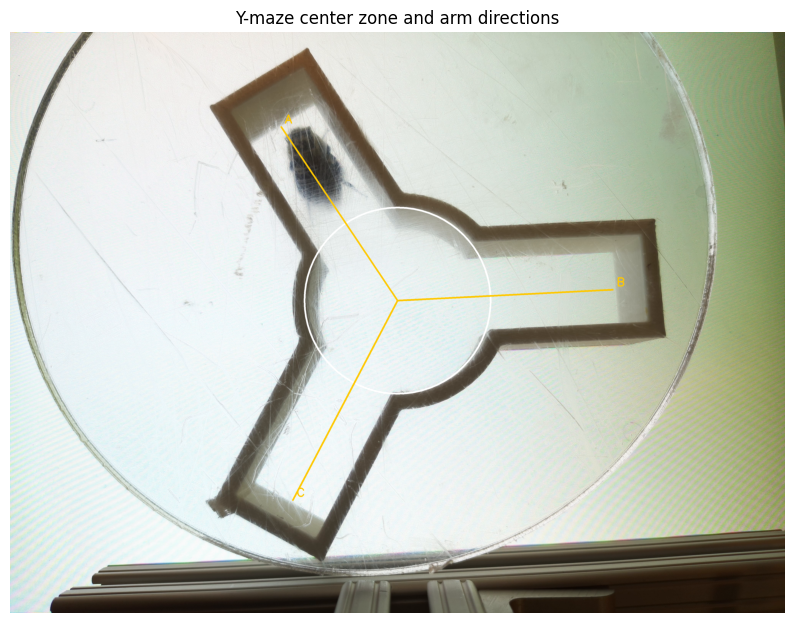

In [282]:
zone_check = reference_frame_rgb.copy()

center_tuple = tuple(
    np.round(center).astype(int)
)

# Draw center zone
cv.circle(
    zone_check,
    center_tuple,
    radius=int(center_radius),
    color=(255, 255, 255),
    thickness=8
)

# Draw arm directions
for arm_name, arm_point in arm_points.items():

    arm_tuple = tuple(
        np.round(arm_point).astype(int)
    )

    cv.line(
        zone_check,
        center_tuple,
        arm_tuple,
        color=(255, 200, 0),
        thickness=8
    )

    cv.putText(
        zone_check,
        arm_name,
        (arm_tuple[0] + 20, arm_tuple[1] - 20),
        cv.FONT_HERSHEY_SIMPLEX,
        2,
        (255, 200, 0),
        thickness=5
    )

plt.figure(figsize=(10, 8))
plt.imshow(zone_check)
plt.title("Y-maze center zone and arm directions")
plt.axis("off")
plt.show()

In [283]:
# determine zone for bee in reference frame

if result.boxes is None or len(result.boxes) == 0:

    print("No bee position is available for zone classification.")

else:

    best_detection_index = np.argmax(confidences)

    best_box = boxes[best_detection_index]
    best_confidence = confidences[best_detection_index]

    x_min, y_min, x_max, y_max = best_box

    bee_x_center = (x_min + x_max) / 2
    bee_y_center = (y_min + y_max) / 2

    bee_zone = classify_maze_zone(
        x=bee_x_center,
        y=bee_y_center,
        center=center,
        arm_vectors=arm_vectors,
        center_radius=center_radius,
        maximum_maze_radius=maximum_maze_radius
    )

    print(f"Bee x-position: {bee_x_center:.1f}")
    print(f"Bee y-position: {bee_y_center:.1f}")
    print(f"YOLO confidence: {best_confidence:.3f}")
    print(f"Classified maze zone: {bee_zone}")

Bee x-position: 1603.8
Bee y-position: 703.1
YOLO confidence: 0.728
Classified maze zone: A


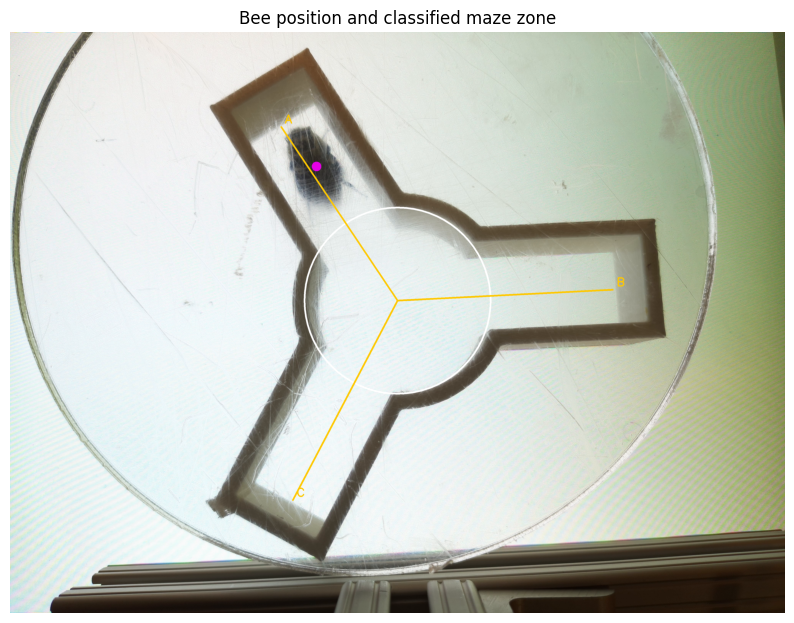

In [284]:
bee_position_check = zone_check.copy()

bee_position_tuple = (
    int(round(bee_x_center)),
    int(round(bee_y_center))
)

cv.circle(
    bee_position_check,
    bee_position_tuple,
    radius=25,
    color=(230, 0, 230),
    thickness=-1
)


plt.figure(figsize=(10, 8))
plt.imshow(bee_position_check)
plt.title("Bee position and classified maze zone")
plt.axis("off")
plt.show()

In [285]:
# Run YOLO on the entire video (takes around 13min per video with CPU, 1.5min per video with T4 GPU)

video_results = model.predict(
    source=str(video_path),
    conf=0.25,
    stream=True,
    verbose=False
)

tracking_rows = []

for frame_number, frame_result in enumerate(video_results):

    time_seconds = frame_number / fps

    # No bee detected in this frame
    if frame_result.boxes is None or len(frame_result.boxes) == 0:

        tracking_rows.append({
            "frame": frame_number,
            "time_seconds": time_seconds,
            "detected": False,
            "number_of_detections": 0,
            "class_name": None,
            "confidence": np.nan,
            "x_min": np.nan,
            "y_min": np.nan,
            "x_max": np.nan,
            "y_max": np.nan,
            "x_center": np.nan,
            "y_center": np.nan,
            "zone": "missing"
        })

        continue

    # Extract all detections from this frame
    frame_boxes = frame_result.boxes.xyxy.cpu().numpy()
    frame_confidences = frame_result.boxes.conf.cpu().numpy()
    frame_class_ids = (
        frame_result.boxes.cls.cpu().numpy().astype(int)
    )

    # Select the detection with the highest confidence
    best_detection_index = np.argmax(frame_confidences)

    best_box = frame_boxes[best_detection_index]
    best_confidence = frame_confidences[best_detection_index]
    best_class_id = frame_class_ids[best_detection_index]

    x_min, y_min, x_max, y_max = best_box

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2

    class_name = model.names[best_class_id]

    zone = classify_maze_zone(
        x=x_center,
        y=y_center,
        center=center,
        arm_vectors=arm_vectors,
        center_radius=center_radius,
        maximum_maze_radius=maximum_maze_radius
    )

    tracking_rows.append({
        "frame": frame_number,
        "time_seconds": time_seconds,
        "detected": True,
        "number_of_detections": len(frame_boxes),
        "class_name": class_name,
        "confidence": best_confidence,
        "x_min": x_min,
        "y_min": y_min,
        "x_max": x_max,
        "y_max": y_max,
        "x_center": x_center,
        "y_center": y_center,
        "zone": zone
    })

In [286]:
# Convert the collected rows into a pandas dataframe
tracking_data = pd.DataFrame(tracking_rows)

In [287]:
# Quality check

detection_rate = tracking_data["detected"].mean()

detected_confidences = tracking_data.loc[
    tracking_data["detected"],
    "confidence"
]

mean_confidence = detected_confidences.mean()
median_confidence = detected_confidences.median()

multiple_detection_rate = (
    tracking_data["number_of_detections"] > 1
).mean()

missing_frames = (~tracking_data["detected"]).sum()

print(f"Detection rate: {detection_rate * 100:.2f}%")
print(f"Mean confidence: {mean_confidence:.3f}")
print(f"Median confidence: {median_confidence:.3f}")
print(f"Missing frames: {missing_frames} of {len(tracking_data)}")
print(
    f"Frames with multiple detections: "
    f"{multiple_detection_rate * 100:.2f}%"
)

zone_counts = tracking_data["zone"].value_counts(
    dropna=False
)

print(zone_counts)

Detection rate: 62.88%
Mean confidence: 0.586
Median confidence: 0.715
Missing frames: 294 of 792
Frames with multiple detections: 0.00%
zone
A          498
missing    294
Name: count, dtype: int64


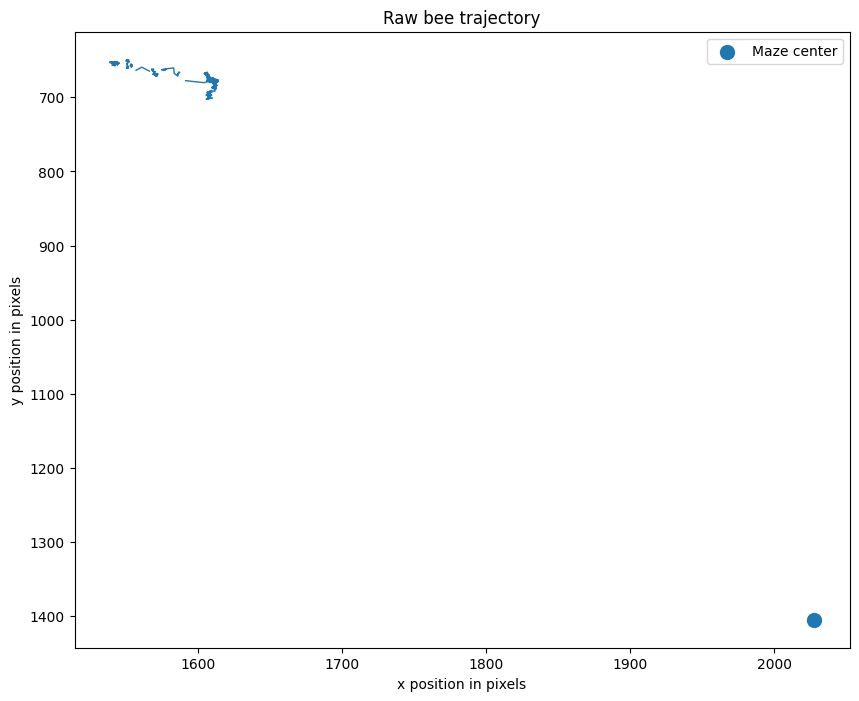

In [288]:
# draw trajectory

plt.figure(figsize=(10, 8))

plt.plot(
    tracking_data["x_center"],
    tracking_data["y_center"],
    linewidth=1
)

plt.scatter(
    center[0],
    center[1],
    s=100,
    label="Maze center"
)

plt.xlabel("x position in pixels")
plt.ylabel("y position in pixels")
plt.title("Raw bee trajectory")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

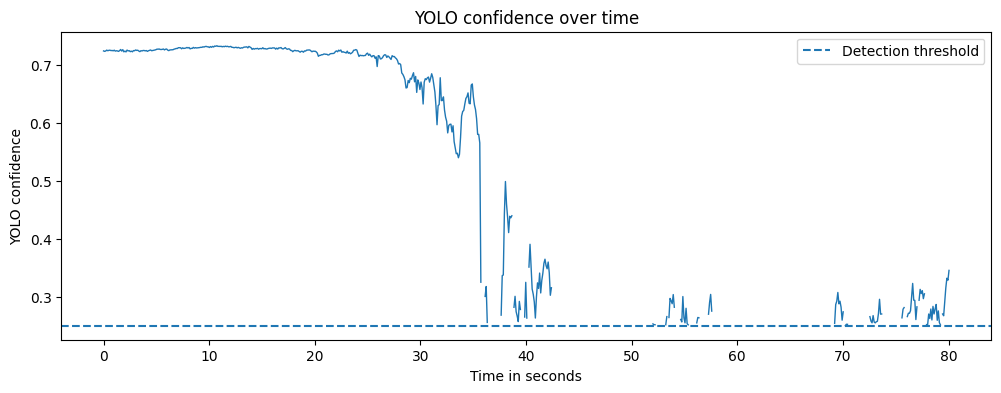

In [289]:
# draw confidence over time

plt.figure(figsize=(12, 4))

plt.plot(
    tracking_data["time_seconds"],
    tracking_data["confidence"],
    linewidth=1
)

plt.axhline(
    0.25,
    linestyle="--",
    label="Detection threshold"
)

plt.xlabel("Time in seconds")
plt.ylabel("YOLO confidence")
plt.title("YOLO confidence over time")
plt.legend()
plt.show()

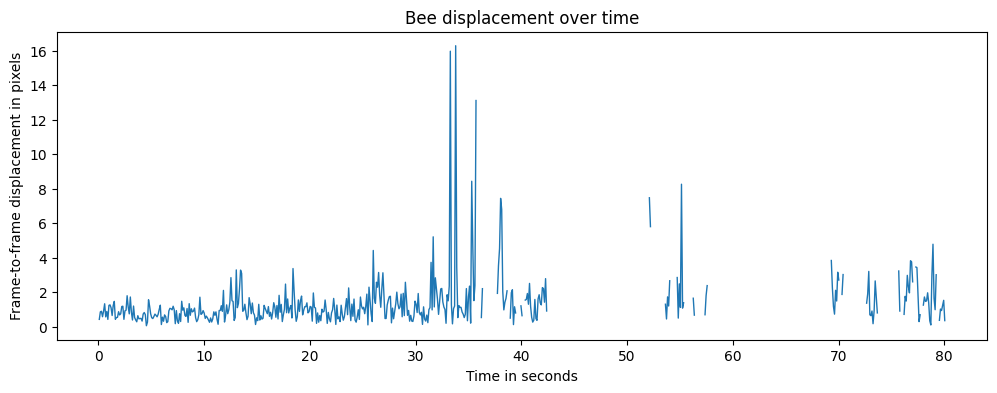

count    470.000000
mean       1.355747
std        1.561008
min        0.053024
50%        0.991798
90%        2.468352
95%        3.284142
99%        7.716252
max       16.289811
Name: displacement, dtype: float64


In [290]:
# Calculate and display frame-to-frame displacement

tracking_data["dx"] = tracking_data["x_center"].diff()
tracking_data["dy"] = tracking_data["y_center"].diff()

tracking_data["displacement"] = np.sqrt(
    tracking_data["dx"] ** 2
    + tracking_data["dy"] ** 2
)

plt.figure(figsize=(12, 4))

plt.plot(
    tracking_data["time_seconds"],
    tracking_data["displacement"],
    linewidth=1
)

plt.xlabel("Time in seconds")
plt.ylabel("Frame-to-frame displacement in pixels")
plt.title("Bee displacement over time")
plt.show()

print(
    tracking_data["displacement"].describe(
        percentiles=[0.90, 0.95, 0.99]
    )
)

In [291]:
# correct displacements

max_jump_pixels = 250

tracking_data["position_valid"] = (
    tracking_data["detected"]
    & (
        tracking_data["displacement"].isna()
        | (tracking_data["displacement"] < max_jump_pixels)
    )
)

tracking_data["x_clean"] = tracking_data["x_center"].where(
    tracking_data["position_valid"]
)

tracking_data["y_clean"] = tracking_data["y_center"].where(
    tracking_data["position_valid"]
)

# define invalid positions

invalid_positions = (~tracking_data["position_valid"]).sum()

print(
    f"Invalid or missing positions: "
    f"{invalid_positions} of {len(tracking_data)} "
    f"({invalid_positions / len(tracking_data) * 100:.2f}%)"
)

Invalid or missing positions: 294 of 792 (37.12%)


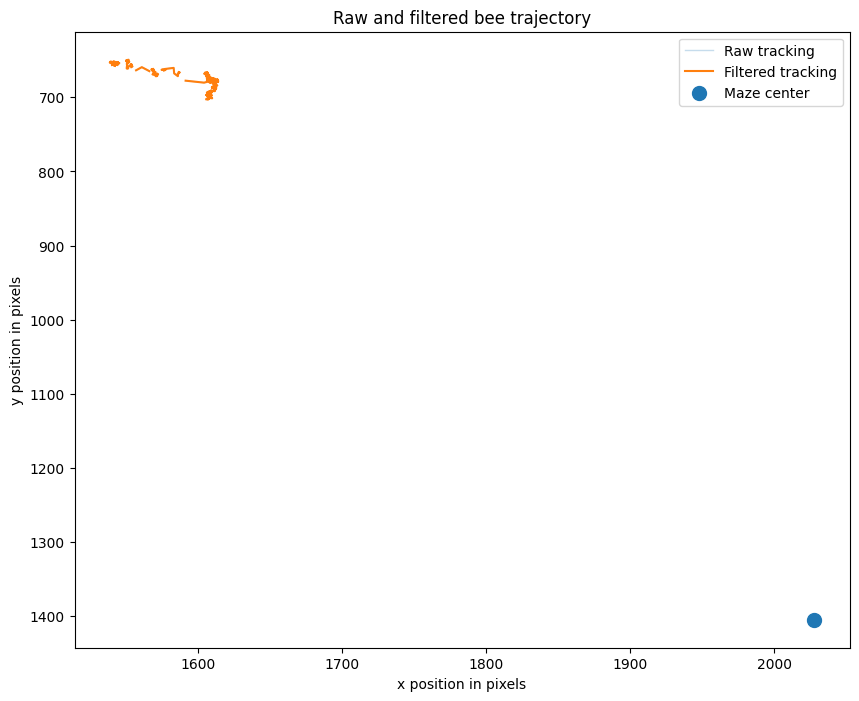

In [292]:
plt.figure(figsize=(10, 8))

plt.plot(
    tracking_data["x_center"],
    tracking_data["y_center"],
    linewidth=1,
    alpha=0.25,
    label="Raw tracking"
)

plt.plot(
    tracking_data["x_clean"],
    tracking_data["y_clean"],
    linewidth=1.5,
    label="Filtered tracking"
)

plt.scatter(
    center[0],
    center[1],
    s=100,
    label="Maze center"
)

plt.xlabel("x position in pixels")
plt.ylabel("y position in pixels")
plt.title("Raw and filtered bee trajectory")
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [293]:
# correct zone determination

tracking_data["zone_clean"] = tracking_data.apply(
    lambda row: classify_maze_zone(
        x=row["x_clean"],
        y=row["y_clean"],
        center=center,
        arm_vectors=arm_vectors,
        center_radius=center_radius,
        maximum_maze_radius=maximum_maze_radius
    ),
    axis=1
)

print(
    tracking_data["zone_clean"].value_counts(
        dropna=False
    )
)

zone_clean
A          498
missing    294
Name: count, dtype: int64


In [294]:
# Summarize consecutive identical zones into runs

def create_zone_runs(zone_series):
    runs = []

    current_zone = None
    start_index = None

    for index, zone in zone_series.items():

        if zone != current_zone:

            # Save the previous run
            if current_zone is not None:
                runs.append({
                    "zone": current_zone,
                    "start_frame": start_index,
                    "end_frame": index - 1,
                    "duration_frames": index - start_index
                })

            current_zone = zone
            start_index = index

    # Save the final run
    if current_zone is not None:
        runs.append({
            "zone": current_zone,
            "start_frame": start_index,
            "end_frame": zone_series.index[-1],
            "duration_frames": zone_series.index[-1] - start_index + 1
        })

    return pd.DataFrame(runs)

zone_runs = create_zone_runs(
    tracking_data["zone_clean"]
)

zone_runs.head(20)

,zone,start_frame,end_frame,duration_frames
0,A,0,353,354
1,missing,354,354,1
2,A,355,355,1
3,missing,356,356,1
4,A,357,359,3
5,missing,360,371,12
6,A,372,382,11
7,missing,383,383,1
8,A,384,390,7
9,missing,391,393,3


In [295]:
# clean this table up (cut out outliers and merge adjacent same zones)

minimum_zone_frames = 5

valid_zones = ["A", "B", "C", "center"]

stable_zone_runs = zone_runs[
    (zone_runs["zone"].isin(valid_zones))
    & (zone_runs["duration_frames"] >= minimum_zone_frames)
].copy()

stable_zone_runs.reset_index(
    drop=True,
    inplace=True
)

stable_zone_runs.head(20)

def merge_adjacent_same_zones(runs_dataframe):
    merged_runs = []

    for _, run in runs_dataframe.iterrows():

        current_zone = run["zone"]

        if (
            len(merged_runs) > 0
            and merged_runs[-1]["zone"] == current_zone
        ):
            merged_runs[-1]["end_frame"] = run["end_frame"]

            merged_runs[-1]["duration_frames"] = (
                merged_runs[-1]["end_frame"]
                - merged_runs[-1]["start_frame"]
                + 1
            )

        else:
            merged_runs.append({
                "zone": current_zone,
                "start_frame": run["start_frame"],
                "end_frame": run["end_frame"],
                "duration_frames": run["duration_frames"]
            })

    return pd.DataFrame(merged_runs)

stable_zone_runs = merge_adjacent_same_zones(
    stable_zone_runs
)

stable_zone_runs = stable_zone_runs.reset_index(drop=True)

print(stable_zone_runs["zone"].tolist()[:30])

['A']


In [296]:
# define decisions

turn_lookup = {
    ("A", "B"): "left",
    ("A", "C"): "right",
    ("B", "C"): "left",
    ("B", "A"): "right",
    ("C", "A"): "left",
    ("C", "B"): "right"
}

def classify_turn(entry_arm, exit_arm):

    if entry_arm == exit_arm:
        return "u_turn"

    return turn_lookup.get(
        (entry_arm, exit_arm),
        "unclear"
    )

In [297]:
decision_rows = []

for index in range(
    1,
    len(stable_zone_runs) - 1
):

    previous_run = stable_zone_runs.iloc[index - 1]
    current_run = stable_zone_runs.iloc[index]
    next_run = stable_zone_runs.iloc[index + 1]

    entry_arm = previous_run["zone"]
    middle_zone = current_run["zone"]
    exit_arm = next_run["zone"]

    # A valid decision must pass through the center

    if (
        middle_zone == "center"
        and entry_arm in ["A", "B", "C"]
        and exit_arm in ["A", "B", "C"]
    ):

        turn_direction = classify_turn(
            entry_arm,
            exit_arm
        )

        decision_rows.append({
            "decision_number": len(decision_rows) + 1,
            "entry_arm": entry_arm,
            "exit_arm": exit_arm,
            "turn_direction": turn_direction,
            "center_entry_frame": current_run["start_frame"],
            "center_exit_frame": current_run["end_frame"],
            "decision_time_seconds": (
                current_run["start_frame"] / fps
            ),
            "center_duration_frames": current_run["duration_frames"],
            "center_duration_seconds": (
                current_run["duration_frames"] / fps
            )
        })

decisions = pd.DataFrame(decision_rows)

decisions

""


In [298]:
# Summarize decisions

# Set default values first.
# This is important for videos with no detected decisions.

number_left = 0
number_right = 0
number_uturn = 0
number_unclear = 0
valid_left_right_decisions = 0

right_turn_proportion = np.nan
laterality_index = np.nan


# Calculate decision metrics if decisions exist

if len(decisions) == 0:

    print("No valid decisions were detected.")

else:

    number_left = (
        decisions["turn_direction"] == "left"
    ).sum()

    number_right = (
        decisions["turn_direction"] == "right"
    ).sum()

    number_uturn = (
        decisions["turn_direction"] == "u_turn"
    ).sum()

    number_unclear = (
        decisions["turn_direction"] == "unclear"
    ).sum()

    valid_left_right_decisions = (
        number_left + number_right
    )

    if valid_left_right_decisions > 0:

        right_turn_proportion = (
            number_right
            / valid_left_right_decisions
        )

        laterality_index = (
            number_right - number_left
        ) / valid_left_right_decisions


    print("Left turns:", number_left)
    print("Right turns:", number_right)
    print("U-turns:", number_uturn)
    print("Unclear:", number_unclear)

    print(
        "Right-turn proportion:",
        round(right_turn_proportion, 3)
    )


# Display decision sequence

if len(decisions) > 0:

    decision_sequence = decisions[
        "turn_direction"
    ].replace({
        "left": "L",
        "right": "R",
        "u_turn": "U",
        "unclear": "?"
    }).tolist()

    print(
        "Decision sequence:",
        " - ".join(decision_sequence)
    )

No valid decisions were detected.


In [299]:
# Calculate distance traveled from cleaned tracking

tracking_data["dx_clean"] = tracking_data["x_clean"].diff()
tracking_data["dy_clean"] = tracking_data["y_clean"].diff()

tracking_data["distance_pixels"] = np.sqrt(
    tracking_data["dx_clean"] ** 2
    + tracking_data["dy_clean"] ** 2
)

# If a position is missing, distance for that step cannot be measured.
# Set it to 0 so it does not artificially increase cumulative distance.
tracking_data["distance_pixels"] = (
    tracking_data["distance_pixels"].fillna(0)
)

tracking_data["cumulative_distance_pixels"] = (
    tracking_data["distance_pixels"].cumsum()
)

total_distance_pixels = (
    tracking_data["distance_pixels"].sum()
)

distance_per_minute = (
    total_distance_pixels
    / duration_seconds
    * 60
)

print(
    "Total distance traveled:",
    round(total_distance_pixels, 1),
    "pixels"
)

print(
    "Distance traveled per minute:",
    round(distance_per_minute, 1),
    "pixels/min"
)

# Save frame-by-frame tracking data for this video

tracking_output_path = (
    results_folder
    / "tracking"
    / f"{video_path.stem}_tracking.csv"
)

tracking_output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

tracking_data.to_csv(
    tracking_output_path,
    index=False
)

print("Tracking data saved at:")
print(tracking_output_path)


# Extract bee ID from video filename

video_filename = video_path.stem

bee_id = None

for part in video_filename.split("_"):
    if part.startswith("bee") and part[3:].isdigit():
        bee_id = part

if bee_id is None:
    raise ValueError(
        f"Bee ID could not be extracted from filename: {video_path.name}"
    )

print("Bee ID:", bee_id)


# Create summary row for current video

new_summary_row = pd.DataFrame([{
    "bee_id": bee_id,
    "video_name": video_path.name,
    "video_quality": video_quality,

    "detection_rate": detection_rate,
    "mean_confidence": mean_confidence,
    "median_confidence": median_confidence,

    "number_left": number_left,
    "number_right": number_right,
    "number_uturn": number_uturn,
    "number_unclear": number_unclear,

    "right_turn_proportion": right_turn_proportion,
    "total_valid_left_right_decisions": valid_left_right_decisions,

    "total_distance_pixels": total_distance_pixels,
    "distance_per_minute": distance_per_minute,

    "video_duration_seconds": duration_seconds
}])


# Define shared summary file

summary_output_path = (
    results_folder
    / "all_video_summary.csv"
)


# Add or update current video in summary

if summary_output_path.exists():

    existing_summary = pd.read_csv(
        summary_output_path
    )

    # Check whether this exact video already exists
    video_already_exists = (
        video_path.name
        in existing_summary["video_name"].values
    )

    if video_already_exists:

        # Remove the old version of this video
        existing_summary = existing_summary[
            existing_summary["video_name"] != video_path.name
        ]

        # Add the newly calculated version
        combined_summary = pd.concat(
            [existing_summary, new_summary_row],
            ignore_index=True
        )

        print(
            "Existing video updated with new analysis results."
        )

    else:

        combined_summary = pd.concat(
            [existing_summary, new_summary_row],
            ignore_index=True
        )

        print(
            "New video added to existing summary."
        )

else:

    combined_summary = new_summary_row

    print(
        "New summary file created."
    )


# Save complete summary

combined_summary.to_csv(
    summary_output_path,
    index=False
)


# Display complete summary

print("Summary saved at:")
print(summary_output_path)

combined_summary

Total distance traveled: 637.2 pixels
Distance traveled per minute: 477.0 pixels/min
Tracking data saved at:
/content/drive/MyDrive/Y-maze handedness/results/tracking/bee_0415_bee5_hand_opto_2026-04-15_23-15-32_tracking.csv
Bee ID: bee5
New video added to existing summary.
Summary saved at:
/content/drive/MyDrive/Y-maze handedness/results/all_video_summary.csv


,bee_id,video_name,video_quality,detection_rate,mean_confidence,median_confidence,number_left,number_right,number_uturn,number_unclear,right_turn_proportion,total_valid_left_right_decisions,total_distance_pixels,distance_per_minute,video_duration_seconds
0,bee6,bee_0409_bee6_hand_opto_2026-04-09_11-48-21.mp4,usable,0.951220,0.682421,0.708594,6,1,0,0,0.142857,7,24407.951592,18272.812928,80.145137
1,bee7,bee_0409_bee7_hand_opto_2026-04-09_12-12-44.mov,usable,0.903743,0.607038,0.666559,3,3,2,0,0.500000,6,18527.229844,13893.389780,80.011704
2,bee8,bee_0409_bee8_hand_opto_2026-04-09_21-07-27.mp4,usable,0.934473,0.664162,0.702281,2,5,0,0,0.714286,7,27782.665063,20825.342592,80.044777
3,bee8,bee_0409_bee8_hand_opto_2026-04-09_21-15-08.mp4,usable,0.888424,0.634232,0.685671,6,0,2,0,0.000000,6,29328.173814,21956.382173,80.144826
4,bee9,bee_0410_bee9_hand_opto_2026-04-10_12-43-59.mp4,usable,0.995714,0.730522,0.734468,5,4,0,0,0.444444,9,36843.866501,27617.470340,80.044695
5,bee10,bee_0410_bee10_hand_opto_2026-04-10_15-37-57.mp4,usable,0.990369,0.726277,0.733493,2,5,0,0,0.714286,7,25861.473996,19385.279787,80.044676
6,bee10,bee_0410_bee10_hand_opto_2026-04-10_15-47-13.mp4,usable,0.997139,0.726216,0.736710,3,2,1,0,0.400000,5,23828.523232,17839.119450,80.144729
7,bee1,bee_0415_bee1_hand_opto_2026-04-15_15-56-39.mp4,usable,1.000000,0.711068,0.710220,0,0,0,0,NaN,0,1456.806641,1093.356323,79.945027
8,bee2,bee_0415_bee2_hand_opto_2026-04-15_19-15-28.mp4,usable,0.998523,0.706597,0.728130,4,3,1,0,0.428571,7,30698.126709,23039.448764,79.944951
9,bee2,bee_0415_bee2_hand_opto_2026-04-15_19-20-41.mp4,usable,0.975783,0.659385,0.689367,5,2,3,0,0.285714,7,36137.808218,27088.094731,80.045072


,bee_id,number_of_videos,number_left,number_right,number_uturn,total_valid_left_right_decisions,right_turn_proportion
0,bee1,1,0,0,0,0,NaN
1,bee2,2,9,5,4,14,0.357143
2,bee3,1,0,0,0,0,NaN
3,bee4,2,0,1,5,1,1.000000
4,bee5,1,0,0,0,0,NaN
5,bee6,1,6,1,0,7,0.142857
6,bee7,1,3,3,2,6,0.500000
7,bee8,2,8,5,2,13,0.384615
8,bee9,1,5,4,0,9,0.444444
9,bee10,2,5,7,1,12,0.583333


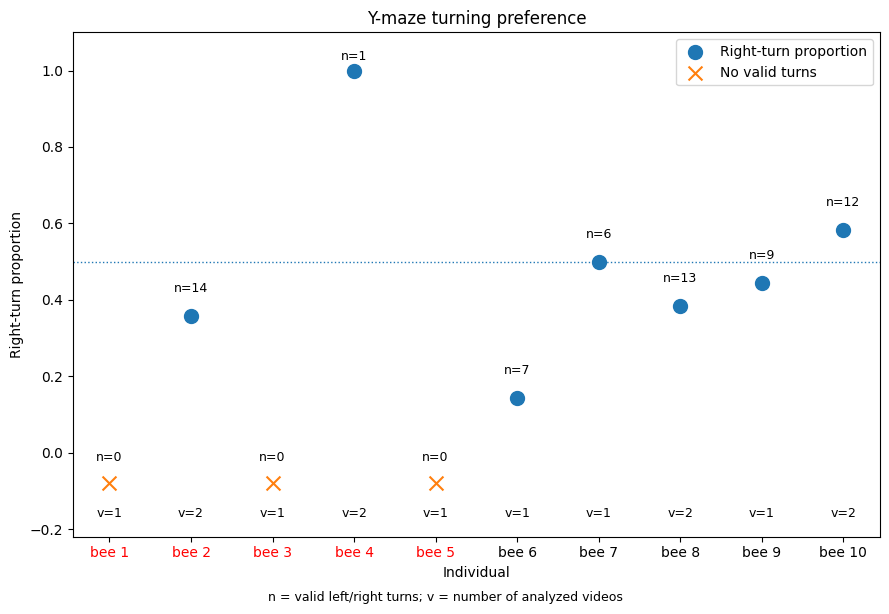

Plot saved at:
/content/drive/MyDrive/Y-maze handedness/results/right_turn_proportion.png


In [300]:
# Load latest summary data

summary_path = Path(
    "/content/drive/MyDrive/"
    "Y-maze handedness/results/"
    "all_video_summary.csv"
)

summary_data = pd.read_csv(summary_path)


# Summarize data per individual

bee_summary = (
    summary_data
    .groupby("bee_id", as_index=False)
    .agg(
        number_left=("number_left", "sum"),
        number_right=("number_right", "sum"),
        number_uturn=("number_uturn", "sum"),

        total_valid_left_right_decisions=(
            "total_valid_left_right_decisions",
            "sum"
        ),

        number_of_videos=("video_name", "nunique")
    )
)


# Calculate right-turn proportion per individual

bee_summary["right_turn_proportion"] = (
    bee_summary["number_right"]
    / (
        bee_summary["number_right"]
        + bee_summary["number_left"]
    )
)


# Extract numeric bee ID and sort numerically

bee_summary["bee_number"] = (
    bee_summary["bee_id"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

bee_summary = (
    bee_summary
    .sort_values("bee_number")
    .reset_index(drop=True)
)


# Cleaner labels for plot

bee_summary["plot_label"] = (
    "bee " + bee_summary["bee_number"].astype(str)
)


# Display summary table for checking

display(
    bee_summary[
        [
            "bee_id",
            "number_of_videos",
            "number_left",
            "number_right",
            "number_uturn",
            "total_valid_left_right_decisions",
            "right_turn_proportion"
        ]
    ]
)


# Create fixed numeric x positions

x_positions = np.arange(len(bee_summary))

has_turns = (
    bee_summary["right_turn_proportion"].notna()
)

no_turns = (
    bee_summary["right_turn_proportion"].isna()
)


# Create plot

plt.figure(figsize=(9, 6))


# Bees with valid left/right decisions

plt.scatter(
    x_positions[has_turns],
    bee_summary.loc[
        has_turns,
        "right_turn_proportion"
    ],
    s=100,
    label="Right-turn proportion"
)


# Bees without valid turns

plt.scatter(
    x_positions[no_turns],
    [-0.08] * no_turns.sum(),
    s=100,
    marker="x",
    label="No valid turns"
)


# Reference line at 0.5

plt.axhline(
    y=0.5,
    linestyle=":",
    linewidth=1
)


# Add consistent labels

for i, row in bee_summary.iterrows():

    # Number of valid turns
    if pd.notna(row["right_turn_proportion"]):

        label_y = min(
            row["right_turn_proportion"] + 0.055,
            1.02
        )

        plt.text(
            i,
            label_y,
            f'n={int(row["total_valid_left_right_decisions"])}',
            ha="center",
            va="bottom",
            fontsize=9
        )

    else:

        plt.text(
            i,
            -0.03,
            "n=0",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Number of videos always at the same height
    plt.text(
        i,
        -0.16,
        f'v={int(row["number_of_videos"])}',
        ha="center",
        va="center",
        fontsize=9
    )


# Format x-axis

plt.xticks(
    x_positions,
    bee_summary["plot_label"]
)


# Nicotine bees (B1-B5) in red
# Control bees (B6-B10) in black

ax = plt.gca()

for tick_label, bee_number in zip(
    ax.get_xticklabels(),
    bee_summary["bee_number"]
):

    if bee_number <= 5:
        tick_label.set_color("red")

    else:
        tick_label.set_color("black")


plt.xlabel("Individual")
plt.ylabel("Right-turn proportion")
plt.title("Y-maze turning preference")

plt.ylim(-0.22, 1.10)


# Legend and explanatory note

plt.legend()

plt.figtext(
    0.5,
    -0.01,
    "n = valid left/right turns; v = number of analyzed videos",
    ha="center",
    fontsize=9
)

plt.tight_layout()


# Save plot

plot_output_path = Path(
    "/content/drive/MyDrive/"
    "Y-maze handedness/results/"
    "right_turn_proportion.png"
)

plt.savefig(
    plot_output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved at:")
print(plot_output_path)

,bee_id,number_of_videos,total_distance_pixels,total_recording_time_seconds,distance_per_minute
0,bee1,1,1456.806641,79.945027,1093.356294
1,bee2,2,66835.934927,159.990023,25065.038559
2,bee3,1,711.816982,80.044938,533.563021
3,bee4,2,33313.034938,160.189749,12477.590537
4,bee5,1,637.201263,80.144858,477.037164
5,bee6,1,24407.951592,80.145137,18272.812928
6,bee7,1,18527.229844,80.011704,13893.389780
7,bee8,2,57110.838877,160.189603,21391.215587
8,bee9,1,36843.866501,80.044695,27617.470340
9,bee10,2,49689.997227,160.189405,18611.716759


Nicotine mean: 7929.3 pixels/min
Control mean: 19957.3 pixels/min


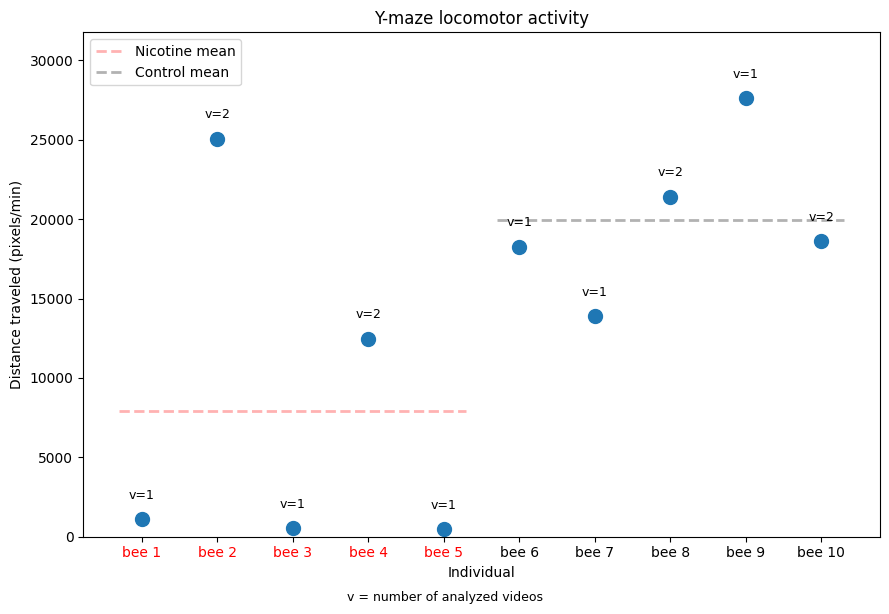

Plot saved at:
/content/drive/MyDrive/Y-maze handedness/results/distance_per_minute.png


In [307]:
# Load latest summary data

summary_path = Path(
    "/content/drive/MyDrive/"
    "Y-maze handedness/results/"
    "all_video_summary.csv"
)

summary_data = pd.read_csv(summary_path)


# Summarize movement data per individual

distance_summary = (
    summary_data
    .groupby("bee_id", as_index=False)
    .agg(
        total_distance_pixels=(
            "total_distance_pixels",
            "sum"
        ),

        total_recording_time_seconds=(
            "video_duration_seconds",
            "sum"
        ),

        number_of_videos=(
            "video_name",
            "nunique"
        )
    )
)


# Calculate distance traveled per minute

distance_summary["distance_per_minute"] = (
    distance_summary["total_distance_pixels"]
    / distance_summary["total_recording_time_seconds"]
    * 60
)


# Extract numeric bee ID and sort numerically

distance_summary["bee_number"] = (
    distance_summary["bee_id"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

distance_summary = (
    distance_summary
    .sort_values("bee_number")
    .reset_index(drop=True)
)


# Cleaner labels for plot

distance_summary["plot_label"] = (
    "bee " + distance_summary["bee_number"].astype(str)
)


# Display summary table for checking

display(
    distance_summary[
        [
            "bee_id",
            "number_of_videos",
            "total_distance_pixels",
            "total_recording_time_seconds",
            "distance_per_minute"
        ]
    ]
)


# Create x positions

x_positions = np.arange(
    len(distance_summary)
)


# Create plot

plt.figure(figsize=(9, 6))

plt.scatter(
    x_positions,
    distance_summary["distance_per_minute"],
    s=100
)

# Calculate group means

nicotine_mask = (
    distance_summary["bee_number"] <= 5
)

control_mask = (
    distance_summary["bee_number"] >= 6
)

nicotine_mean = (
    distance_summary.loc[
        nicotine_mask,
        "distance_per_minute"
    ].mean()
)

control_mean = (
    distance_summary.loc[
        control_mask,
        "distance_per_minute"
    ].mean()
)

print(
    "Nicotine mean:",
    round(nicotine_mean, 1),
    "pixels/min"
)

print(
    "Control mean:",
    round(control_mean, 1),
    "pixels/min"
)


# Add group mean lines

nicotine_positions = x_positions[nicotine_mask]
control_positions = x_positions[control_mask]

plt.hlines(
    y=nicotine_mean,
    xmin=nicotine_positions.min() - 0.3,
    xmax=nicotine_positions.max() + 0.3,
    color="red",
    linewidth=2,
    linestyle="--",
    alpha=0.3,
    label="Nicotine mean"
)

plt.hlines(
    y=control_mean,
    xmin=control_positions.min() - 0.3,
    xmax=control_positions.max() + 0.3,
    color="black",
    linewidth=2,
    linestyle="--",
    alpha=0.3,
    label="Control mean"
)

# Add number of videos

max_distance = distance_summary["distance_per_minute"].max()

label_offset = max_distance * 0.04

for i, row in distance_summary.iterrows():

    plt.text(
        i,
        row["distance_per_minute"] + label_offset,
        f'v={int(row["number_of_videos"])}',
        ha="center",
        va="bottom",
        fontsize=9
    )


# Format x-axis

plt.xticks(
    x_positions,
    distance_summary["plot_label"]
)

ax = plt.gca()


# Nicotine bees B1-B5 in red
# Control bees B6-B10 in black

for tick_label, bee_number in zip(
    ax.get_xticklabels(),
    distance_summary["bee_number"]
):

    if bee_number <= 5:
        tick_label.set_color("red")

    else:
        tick_label.set_color("black")


# Labels and title

plt.xlabel("Individual")
plt.ylabel("Distance traveled (pixels/min)")
plt.title("Y-maze locomotor activity")

plt.ylim(
    0,
    max_distance * 1.15
)


# Explanatory note

plt.figtext(
    0.5,
    -0.01,
    "v = number of analyzed videos",
    ha="center",
    fontsize=9
)

plt.tight_layout()


# Save plot

plot_output_path = Path(
    "/content/drive/MyDrive/"
    "Y-maze handedness/results/"
    "distance_per_minute.png"
)

plt.savefig(
    plot_output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.legend()

plt.show()

print("Plot saved at:")
print(plot_output_path)